# Medidas de Forma

As **medidas de forma**, como o próprio nome diz, são indicadores que buscam resumir a forma da distribuição de probabilidades da variável. Nessa aula será abordada a teoria e aplicação prática na linguagem de programação Python de duas dessas medidas, sendo elas: **Assimetria** e **Curtose**.

## Importando as bibliotecas

In [34]:
from IPython.display import Image
import scipy
import numpy as np
import matplotlib.pyplot as plt
import statistics as st
from scipy.stats import truncnorm
import seaborn as sns

In [46]:
# Faz o download das imagens
!gdown 1B_t9Qo_wGPF7C-6YRiqi5yvyZJlD9s-l
!gdown 1UclkdS56-EmfC1TsAprLNDYd2QNxXmn1
!gdown 1CWdVvh6h86m9hPz5wyiadYBo4PkgDA76
!gdown 1F-jYq2e-bf9g_epqCWy1C4Vts4LlnmDo

Downloading...
From: https://drive.google.com/uc?id=1B_t9Qo_wGPF7C-6YRiqi5yvyZJlD9s-l
To: /content/dist_sim.png
100% 26.5k/26.5k [00:00<00:00, 54.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1UclkdS56-EmfC1TsAprLNDYd2QNxXmn1
To: /content/dist_assim_dir.png
100% 37.3k/37.3k [00:00<00:00, 57.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1CWdVvh6h86m9hPz5wyiadYBo4PkgDA76
To: /content/dist_assim_esq.png
100% 39.4k/39.4k [00:00<00:00, 62.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1F-jYq2e-bf9g_epqCWy1C4Vts4LlnmDo
To: /content/curtose.png
100% 206k/206k [00:00<00:00, 10.4MB/s]


## Coeficiente de Assimetria de Fisher

A métrica $\operatorname{Assimetria}(X)$ fornece o Coeficiente de Assimetria de Fisher (CAF):

$$
\operatorname{Assimetria}(X)=\frac{\sum_{i=1}^n\left(x_i-\bar{x}\right)^3 / n}{\left(\sum_{i=1}^n\left(x_i-\bar{x}\right)^2 / n\right)^{3 / 2}}
$$


Com sua aplicação pode-se classificar a distribuição dos dados em:

### 1. **Distribuição Simétrica**

Quando o (CAF) for igual a 0, a distribuição da variável é considerada como simétrica.

#### O que isso significa?

Significa que os dados estão concentrados em um ponto central (Média | Moda | Mediana). De modo que ao afastar-se do centro, a frequência da valores tende a reduzir tanto para a esquerda, quanto para a direita em uma quantidade parecida. Nota-se pela Figura abaixo que ao traçar uma linha no centro da distribuição, o lado esquerdo e direito tende a ser semelhantes. Outro comportamento interessante é que uma distribuição simétrica apresenta medidas iguais de Média, Mediana e Moda.

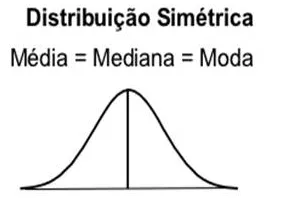

In [14]:
# Plot the figure dist_sim.png
Image('dist_sim.png')

In [15]:
## Distribuição normal:
from scipy.stats import norm

In [21]:
#---------------------------------------------------------
# Simulando 1000 registros com média 0 e desvio padrão 1:
#Gerando a distribuição normal:
dist = norm(loc=0, scale=1)
np.random.seed(225)
simu = dist.rvs(size=1000)
#---------------------------------------------------------

In [24]:
# rvs = Random VariateS of given type.
scipy.stats.norm.rvs?

In [26]:
#simu

In [29]:
#---------------------------------------------------------
# Calculando o coeficente de Assimetria:
CAF = abs(round(scipy.stats.skew(simu),0))
#---------------------------------------------------------
CAF

np.float64(0.0)

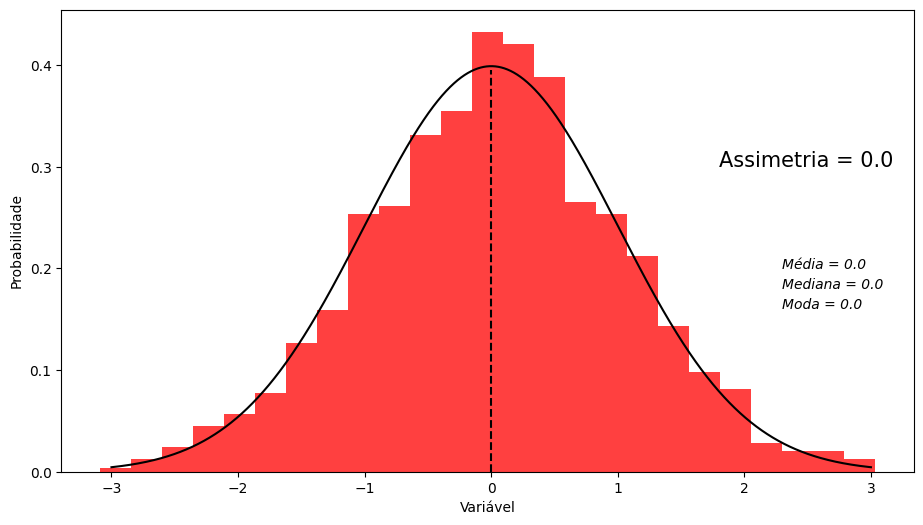

In [30]:
#---------------------------------------------------------
#Calculando a Média, Moda e Mediana:
media = round(st.mean(simu),0)
mediana = round(st.median(simu),0)
moda= round(st.mode(simu),0)
#---------------------------------------------------------

#---------------------------------------------------------
## Criando um histograma e o formato da distribuição:
plt.figure(figsize =(11, 6))
n, bins, patches = plt.hist(simu, density=True, facecolor='red', alpha=0.75, bins=25)
#Criando o intervalo da curva:
intervalo = np.linspace(0-3*1,0+3*1, num=50000)

plt.plot(intervalo, dist.pdf(intervalo), 'k-', label='pdf')
plt.axvline(x=0, ymin=0.0, ymax=0.87, color = 'black', linestyle="--" )
plt.text(1.8, 0.3, f'Assimetria = {CAF}', fontsize = 15)
plt.text(2.3, 0.2, f'Média = {media}', fontsize = 10, multialignment = 'right', fontstyle = 'italic')
plt.text(2.3, 0.18, f'Mediana = {mediana}', fontsize = 10, multialignment = 'right' , fontstyle = 'italic')
plt.text(2.3, 0.16, f'Moda = {moda}', fontsize = 10, multialignment = 'right' , fontstyle = 'italic')
plt.xlabel('Variável')
plt.ylabel('Probabilidade')

#plt.title('Distribuição normal')
plt.grid(False)
plt.show()

#---------------------------------------------------------

### 2. **Distribuição Assimétrica à direita**

Quando o (CAF) for maior que 0 (Positivo) , constata-se que a distribuição da variável apresenta uma assimetria à direita.

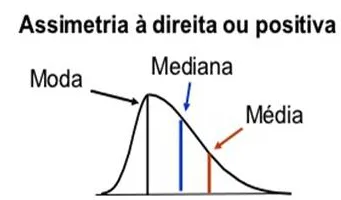

In [31]:
# Plot the figure
Image('dist_assim_dir.png')

#### O que isso significa?

Os dados tendem a ter uma maior concentração no lado esquerdo e os valores se espalham no sentido do lado positivo (valores crescentes | maiores), criando um formato de cauda que se estende pelo lado direito, conforme apresentado na Figura acima. Nesse comportamento, na maior parte das vezes a média apresenta um valor maior que a mediana e a mediana é maior do que a moda.

## Visualizando com Python

In [44]:
truncnorm.rvs?

Média simulada: 6.918652427399909
Mediana simulada: 5.686667029130107
Moda simulada: 4.481029084068707
Assimetria: 1.15


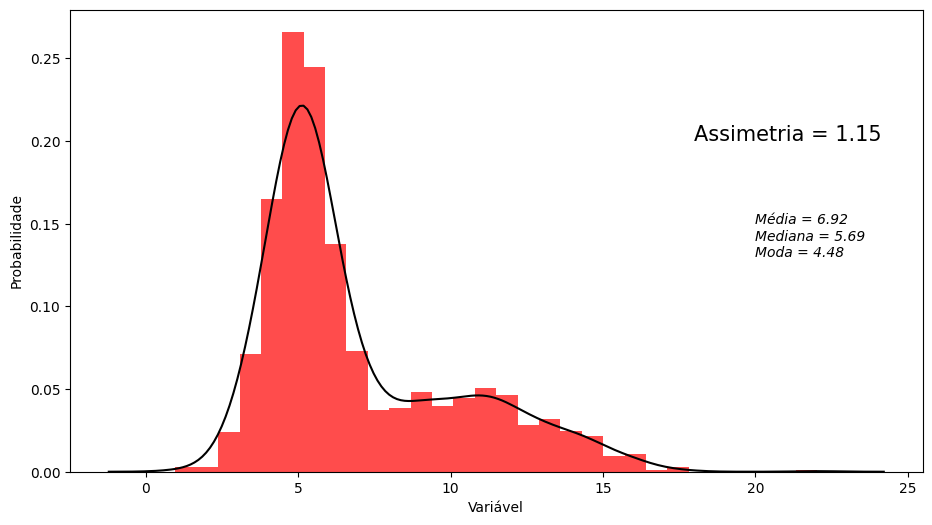

In [45]:
# Parâmetros para a distribuição:
a, b = (1 - 5) / np.sqrt(0.9), np.inf

# Simulando dados com média 5 e variância 0.9
mean, var = 5, 0.9
std = np.sqrt(var)

# Gerando dados com distribuição normal truncada
np.random.seed(225)
data1 = truncnorm.rvs(a, b, loc=5, scale=std, size=1000)
data2 = truncnorm.rvs(a, b, loc=10, scale=3, size=600)
data = np.concatenate([data1, data2])


#---------------------------------------------------------
# Calculando o coeficente de Assimetria:
CAF = round(scipy.stats.skew(data),2)
#---------------------------------------------------------

#---------------------------------------------------------
#Calculando a Média, Moda e Mediana:
media = round(st.mean(data),2)
mediana = round(st.median(data),2)
moda= round(st.mode(data),2)


#---------------------------------------------------------
## Criando um histograma e o formato da distribuição:
plt.figure(figsize =(11, 6))
# Visualizando a distribuição
plt.hist(data, bins=30, density=True, alpha=0.7, color='red')
sns.kdeplot(data, color='black', label='Densidade')
plt.text(18, 0.2, f'Assimetria = {CAF}', fontsize = 15)
plt.text(20, 0.15, f'Média = {media}', fontsize = 10, multialignment = 'right', fontstyle = 'italic')
plt.text(20, 0.14, f'Mediana = {mediana}', fontsize = 10, multialignment = 'right' , fontstyle = 'italic')
plt.text(20, 0.13, f'Moda = {moda}', fontsize = 10, multialignment = 'right' , fontstyle = 'italic')
plt.xlabel('Variável')
plt.ylabel('Probabilidade')

# Mostrando a média e a variância simuladas
print(f"Média simulada: {np.mean(data)}")
print(f"Mediana simulada: {np.median(data)}")
print(f"Moda simulada: {st.mode(data)}")
print(f"Assimetria: {round(scipy.stats.skew(data),2)}")

plt.show()

#---------------------------------------------------------


### 3. **Distribuição Assimétrica à Esquerda**

Quando o (CAF) for menor que 0 (Negativo), a distribuição da variável é considerada como assimétrica à esquerda.

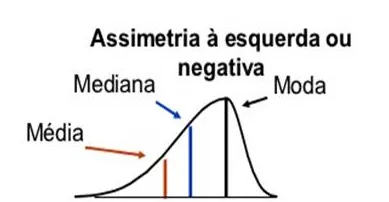

In [36]:
# Plot the figure
Image('dist_assim_esq.png')

### O que isso Significa?

Seria o inverso da caso relatado no tópico anterior, nesse cenário a distribuição da variável tende a estar concentrada no lado direito e os dados empalham-se para o lado negativo (valores decrescentes | menores), gerando uma cauda pelo lado esquerdo. Nessa situação, na maior parte das vezes a moda é maior que a mediana e a mediana é maior que a média.

Média simulada: 3.3561524273999095
Mediana simulada: 4.412997160442967
Moda simulada: 4.481029084068707
Assimetria: -1.25


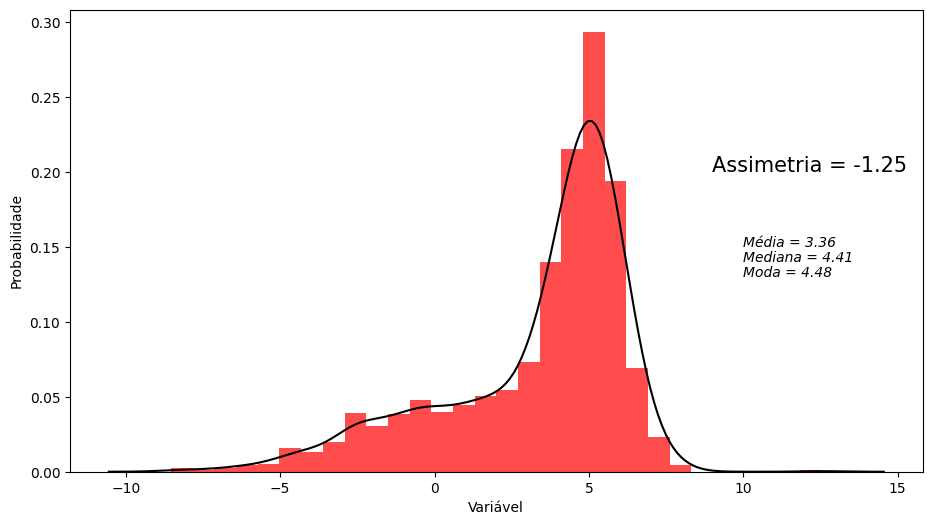

In [51]:
# Parâmetros para a distribuição:
a, b = (1 - 5) / np.sqrt(0.9), np.inf

# Simulando dados com média 5 e variância 0.9
mean, var = 5, 0.9
std = np.sqrt(var)

# Gerando dados com distribuição normal truncada
np.random.seed(225)
data1 = truncnorm.rvs(a, b, loc=5, scale=std, size=1000)
data2 = truncnorm.rvs(a, b, loc=0.5, scale=3, size=600)
data_novo = np.concatenate([data1, data2])


#---------------------------------------------------------
# Calculando o coeficente de Assimetria:
CAF = round(scipy.stats.skew(data_novo),2)
#---------------------------------------------------------

#---------------------------------------------------------
#Calculando a Média, Moda e Mediana:
media = round(st.mean(data_novo),2)
mediana = round(st.median(data_novo),2)
moda= round(st.mode(data_novo),2)


#---------------------------------------------------------
## Criando um histograma e o formato da distribuição:
plt.figure(figsize =(11, 6))
# Visualizando a distribuição
plt.hist(data_novo, bins=30, density=True, alpha=0.7, color='red')
sns.kdeplot(data_novo, color='black', label='Densidade')
plt.text(9, 0.2, f'Assimetria = {CAF}', fontsize = 15)
plt.text(10, 0.15, f'Média = {media}', fontsize = 10, multialignment = 'right', fontstyle = 'italic')
plt.text(10, 0.14, f'Mediana = {mediana}', fontsize = 10, multialignment = 'right' , fontstyle = 'italic')
plt.text(10, 0.13, f'Moda = {moda}', fontsize = 10, multialignment = 'right' , fontstyle = 'italic')
plt.xlabel('Variável')
plt.ylabel('Probabilidade')

# Mostrando a média e a variância simuladas
print(f"Média simulada: {np.mean(data_novo)}")
print(f"Mediana simulada: {np.median(data_novo)}")
print(f"Moda simulada: {st.mode(data_novo)}")
print(f"Assimetria: {round(scipy.stats.skew(data_novo),2)}")

plt.show()

#---------------------------------------------------------

# Curtose

De maneira simples, a curtose representa o grau de achatamento da distribuição da variável, isto é: quanto mais achatada for a curva, mais espalhados os dados estão em relação média, e o inverso é válido. A curtose pode ser representada pela fórmula abaixo:


$$
\operatorname{Curtose}(X)=\frac{\sum_{i=1}^n\left(x_i-\bar{x}\right)^4 / n}{\left(\sum_{i=1}^n\left(x_i-\bar{x}\right)^2 / n\right)^2}-3
$$

Essa equação é conhecida como Coeficiente de Curtose de Fisher (CCF).

A curtose pode ser classificada em três tipos:

- Mesocúrtica: Quando (CCF) = 0. Consideramos a própria distribuição normal padrão.

- Platicúrtica: Quando (CCF) < 0 (Negativo) . Implicando em um achatamento maior que a mesocúrtica, ou seja, os dados encontram-se mais espalhados, indicando uma maior variabilidade.

- Leptocúrtica: Quando (CCF) > 0 (Positivo). Apresentando um achatamento menor do que a mesocúrtica, tendo uma maior concentração dos dados em torno da média, e consequentemente, uma menor variabilidade.

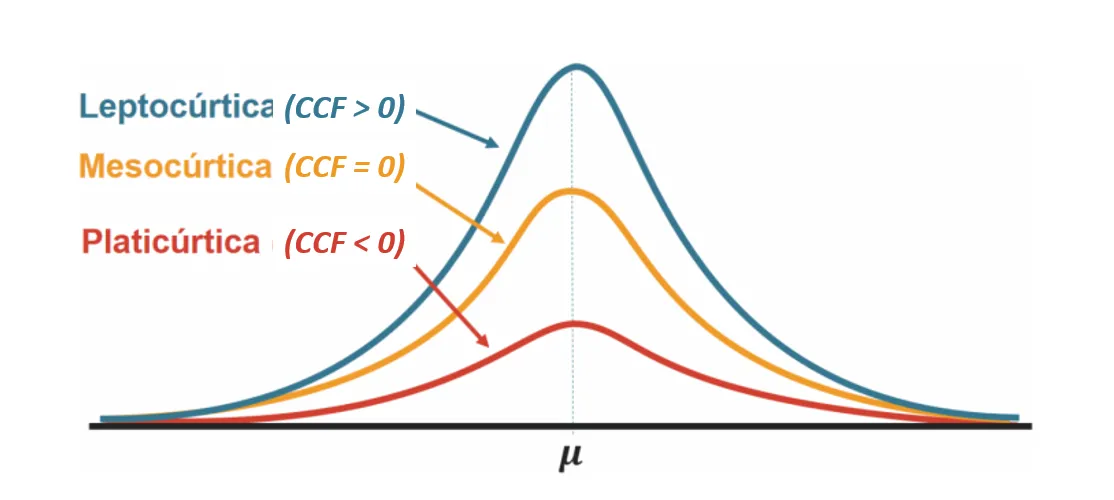

In [47]:
# Plot the figure
Image('curtose.png')

Para calcular o (CCF) no Python pode-se usar a função kurtosis da biblioteca scipy. No exemplo abaixo, vamos calcular o (CCF) para a distribuição dos casos acima. Nota-se que o (CCF) foi igual a 0, classificando-a como Mesocúrtica.

In [49]:
# Distribuição Simétrica
print(f'Coeficiente de Curtose Fisher: {round(scipy.stats.kurtosis(simu),0)}')

Coeficiente de Curtose Fisher: -0.0


In [50]:
# Distribuição Assimétrica à direita
print(f'Coeficiente de Curtose Fisher: {round(scipy.stats.kurtosis(data),0)}')

Coeficiente de Curtose Fisher: 1.0


In [53]:
# Distribuição Assimétrica à esquerda
print(f'Coeficiente de Curtose Fisher: {round(scipy.stats.kurtosis(data_novo),0)}')

Coeficiente de Curtose Fisher: 1.0


Os dois casos assimétricos têm curtose leptocúrtica.